# 🏥 Massachusetts General Hospital — Patient Records Analysis

| | |
|---|---|
| **Dataset** | Synthetic data on ~1,000 patients — 2011 to 2022 |
| **Source**  | Synthea Synthetic Patient Generator |
| **Analyst** | Dr. Bahaa — Bahaa Pharmacy, Data Analytics Division |
| **Date**    | May 2026 |

---

## 🎯 Project Objectives

| # | Objective | Key Questions |
|---|---|---|
| 1 | **Encounters Overview** | Volume trends, encounter class breakdown, length of stay |
| 2 | **Cost & Coverage Insights** | Claim costs, payer coverage, expensive procedures |
| 3 | **Patient Behavior** | Admissions over time, 30-day readmissions, top readmitted patients |

---

## 📁 Dataset Files

| File | Description | Records |
|---|---|---|
| `patients.csv`     | Patient demographics                    | 973    |
| `encounters.csv`   | Hospital visits with cost & payer info  | 27,890 |
| `procedures.csv`   | Procedures performed per encounter      | 47,700 |
| `payers.csv`       | Insurance companies                     | 9      |
| `organizations.csv`| Hospital info                           | 1      |

---

## 🗂️ Notebook Structure

1. Setup & Library Imports
2. Data Loading & First Look
3. Data Cleaning & Type Casting
4. KPI Summary
5. Objective 1 — Encounters Overview
6. Objective 2 — Cost & Coverage Insights
7. Objective 3 — Patient Behavior Analysis
8. Final Dashboard

---

## Step 1 — Setup & Library Imports

In this step we import all the Python libraries we will need throughout
the entire notebook:

- **pandas**     → data loading, cleaning, and manipulation
- **numpy**      → numerical operations
- **matplotlib** → base plotting engine
- **seaborn**    → statistical visualizations built on top of matplotlib
- **warnings**   → to suppress non-critical warnings and keep output clean

We also set global display and chart style options here so every table
and visualization looks consistent across the whole notebook.

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# ── Global Settings ─────────────────────────────────────────────────
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_colwidth', 60)

# ── Chart Style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 130,
    'figure.facecolor'  : '#F8F9FA',
    'axes.facecolor'    : '#FFFFFF',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 10,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'legend.fontsize'   : 9,
    'font.family'       : 'DejaVu Sans',
})

# ── Project Color Palette ────────────────────────────────────────────
PALETTE    = sns.color_palette('Blues_d', 10)
COLOR_MAIN = '#1A6FA8'   # primary blue
COLOR_ACC  = '#E84545'   # accent red  (alerts / highlights)
COLOR_OK   = '#2ECC71'   # green       (positive metrics)

print('✅ All libraries imported successfully.')
print(f'   pandas     : {pd.__version__}')
print(f'   numpy      : {np.__version__}')
print(f'   matplotlib : {plt.matplotlib.__version__}')
print(f'   seaborn    : {sns.__version__}')

✅ All libraries imported successfully.
   pandas     : 3.0.2
   numpy      : 2.4.4
   matplotlib : 3.10.9
   seaborn    : 0.13.2


## Step 2 — Data Loading & First Look

In this step we load all 5 CSV files into pandas DataFrames and do
a quick first inspection of each one to understand:

- The shape of each table (rows × columns)
- Column names and data types
- A sample of the first few rows
- Any immediately visible issues (nulls, wrong types, etc.)

This gives us a solid foundation before we touch anything in the data.

### Files we load:
| DataFrame | File |
|---|---|
| `patients_df`     | patients.csv     |
| `encounters_df`   | encounters.csv   |
| `procedures_df`   | procedures.csv   |
| `payers_df`       | payers.csv       |
| `organizations_df`| organizations.csv|

In [2]:
# ── Load all CSV files ───────────────────────────────────────────────
patients_df      = pd.read_csv('patients.csv')
encounters_df    = pd.read_csv('encounters.csv')
procedures_df    = pd.read_csv('procedures.csv')
payers_df        = pd.read_csv('payers.csv')
organizations_df = pd.read_csv('organizations.csv')

# ── Shape summary ────────────────────────────────────────────────────
dataframes = {
    'patients'      : patients_df,
    'encounters'    : encounters_df,
    'procedures'    : procedures_df,
    'payers'        : payers_df,
    'organizations' : organizations_df,
}

print('📦 Dataset Overview')
print('=' * 45)
for name, df in dataframes.items():
    print(f'  {name:<16} → {df.shape[0]:>6,} rows  × {df.shape[1]:>2} cols')

# ── Inspect each DataFrame ───────────────────────────────────────────
for name, df in dataframes.items():
    print(f'\n{"="*55}')
    print(f'  📄 {name.upper()}')
    print(f'{"="*55}')
    print(df.info())
    print('\n  First 3 rows:')
    display(df.head(3))

📦 Dataset Overview
  patients         →    974 rows  × 20 cols
  encounters       → 27,891 rows  × 14 cols
  procedures       → 47,701 rows  ×  9 cols
  payers           →     10 rows  ×  7 cols
  organizations    →      1 rows  ×  8 cols

  📄 PATIENTS
<class 'pandas.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          974 non-null    str    
 1   BIRTHDATE   974 non-null    str    
 2   DEATHDATE   154 non-null    str    
 3   PREFIX      974 non-null    str    
 4   FIRST       974 non-null    str    
 5   LAST        974 non-null    str    
 6   SUFFIX      21 non-null     str    
 7   MAIDEN      386 non-null    str    
 8   MARITAL     973 non-null    str    
 9   RACE        974 non-null    str    
 10  ETHNICITY   974 non-null    str    
 11  GENDER      974 non-null    str    
 12  BIRTHPLACE  974 non-null    str    
 13  ADDRESS     974 non-null    str  

,Id,BIRTHDATE,DEATHDATE,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON
0,5605b66b-e92d-c16c-1b83-b8bf7040d51f,1977-03-19,NaN,Mrs.,Nikita578,Erdman779,NaN,Leannon79,M,white,nonhispanic,F,Wakefield Massachusetts US,510 Little Station Unit 69,Quincy,Massachusetts,Norfolk County,"2,186.00",42.29,-70.98
1,6e5ae27c-8038-7988-e2c0-25a103f01bfa,1940-02-19,NaN,Mr.,Zane918,Hodkiewicz467,NaN,NaN,M,white,nonhispanic,M,Brookline Massachusetts US,747 Conn Throughway,Boston,Massachusetts,Suffolk County,"2,135.00",42.31,-71.06
2,8123d076-0886-9007-e956-d5864aa121a7,1958-06-04,NaN,Mr.,Quinn173,Marquardt819,NaN,NaN,M,white,nonhispanic,M,Gardner Massachusetts US,816 Okuneva Extension Apt 91,Quincy,Massachusetts,Norfolk County,"2,170.00",42.27,-70.97



  📄 ENCOUNTERS
<class 'pandas.DataFrame'>
RangeIndex: 27891 entries, 0 to 27890
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   27891 non-null  str    
 1   START                27891 non-null  str    
 2   STOP                 27891 non-null  str    
 3   PATIENT              27891 non-null  str    
 4   ORGANIZATION         27891 non-null  str    
 5   PAYER                27891 non-null  str    
 6   ENCOUNTERCLASS       27891 non-null  str    
 7   CODE                 27891 non-null  int64  
 8   DESCRIPTION          27891 non-null  str    
 9   BASE_ENCOUNTER_COST  27891 non-null  float64
 10  TOTAL_CLAIM_COST     27891 non-null  float64
 11  PAYER_COVERAGE       27891 non-null  float64
 12  REASONCODE           8350 non-null   float64
 13  REASONDESCRIPTION    8350 non-null   str    
dtypes: float64(4), int64(1), str(9)
memory usage: 9.2 MB
None

  First 3 rows:


,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,32c84703-2481-49cd-d571-3899d5820253,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,"1,018.02",0.00,NaN,NaN
1,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,"2,619.36",0.00,NaN,NaN
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03T14:32:11Z,2011-01-03T14:47:11Z,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,461.59,305.27,NaN,NaN



  📄 PROCEDURES
<class 'pandas.DataFrame'>
RangeIndex: 47701 entries, 0 to 47700
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   START              47701 non-null  str    
 1   STOP               47701 non-null  str    
 2   PATIENT            47701 non-null  str    
 3   ENCOUNTER          47701 non-null  str    
 4   CODE               47701 non-null  int64  
 5   DESCRIPTION        47701 non-null  str    
 6   BASE_COST          47701 non-null  int64  
 7   REASONCODE         10756 non-null  float64
 8   REASONDESCRIPTION  10756 non-null  str    
dtypes: float64(1), int64(2), str(6)
memory usage: 10.5 MB
None

  First 3 rows:


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,32c84703-2481-49cd-d571-3899d5820253,265764009,Renal dialysis (procedure),903,NaN,NaN
1,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,c98059da-320a-c0a6-fced-c8815f3e3f39,76601001,Intramuscular injection,2477,NaN,NaN
2,2011-01-04T14:49:55Z,2011-01-04T15:04:55Z,d856d6e6-4c98-e7a2-129b-44076c63d008,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,703423002,Combined chemotherapy and radiation therapy (procedure),11620,"363,406,005.00",Malignant tumor of colon



  📄 PAYERS
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   10 non-null     str    
 1   NAME                 10 non-null     str    
 2   ADDRESS              9 non-null      str    
 3   CITY                 9 non-null      str    
 4   STATE_HEADQUARTERED  9 non-null      str    
 5   ZIP                  9 non-null      float64
 6   PHONE                9 non-null      str    
dtypes: float64(1), str(6)
memory usage: 1.5 KB
None

  First 3 rows:


,Id,NAME,ADDRESS,CITY,STATE_HEADQUARTERED,ZIP,PHONE
0,b3221cfc-24fb-339e-823d-bc4136cbc4ed,Dual Eligible,7500 Security Blvd,Baltimore,MD,"21,244.00",1-877-267-2323
1,7caa7254-5050-3b5e-9eae-bd5ea30e809c,Medicare,7500 Security Blvd,Baltimore,MD,"21,244.00",1-800-633-4227
2,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,Medicaid,7500 Security Blvd,Baltimore,MD,"21,244.00",1-877-267-2323



  📄 ORGANIZATIONS
<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Id       1 non-null      str    
 1   NAME     1 non-null      str    
 2   ADDRESS  1 non-null      str    
 3   CITY     1 non-null      str    
 4   STATE    1 non-null      str    
 5   ZIP      1 non-null      int64  
 6   LAT      1 non-null      float64
 7   LON      1 non-null      float64
dtypes: float64(2), int64(1), str(5)
memory usage: 285.0 bytes
None

  First 3 rows:


,Id,NAME,ADDRESS,CITY,STATE,ZIP,LAT,LON
0,d78e84ec-30aa-3bba-a33a-f29a3a454662,MASSACHUSETTS GENERAL HOSPITAL,55 FRUIT STREET,BOSTON,MA,2114,42.36,-71.07


## Step 3 — Data Cleaning & Type Casting

Based on our first look in Step 2, we identified the following issues
that need to be fixed before any analysis:

### 🔧 Actions we will perform:

| Table        | Action                                                      |
|---|---|
| patients     | Convert BIRTHDATE & DEATHDATE to datetime                   |
| patients     | Calculate AGE from BIRTHDATE                                |
| patients     | Drop irrelevant columns (PREFIX, SUFFIX, MAIDEN)            |
| encounters   | Convert START & STOP to datetime                            |
| encounters   | Extract YEAR and MONTH from START                           |
| encounters   | Calculate LOS_HOURS (length of stay in hours)               |
| encounters   | Standardize ENCOUNTERCLASS text (lowercase + strip)         |
| procedures   | Convert START & STOP to datetime                            |
| procedures   | Convert BASE_COST from int64 to float64                     |

After cleaning, we print a confirmation summary to verify
every column has the correct type.

In [3]:
# ════════════════════════════════════════════════════════
#  PATIENTS
# ════════════════════════════════════════════════════════

# Convert date columns to datetime
patients_df['BIRTHDATE']  = pd.to_datetime(patients_df['BIRTHDATE'])
patients_df['DEATHDATE']  = pd.to_datetime(patients_df['DEATHDATE'])

# Calculate AGE
# For living patients  → age based on today
# For deceased patients → age at time of death
today = pd.Timestamp('2026-05-20')

patients_df['AGE'] = patients_df.apply(
    lambda row: int(
        (row['DEATHDATE'] - row['BIRTHDATE']).days / 365.25
    ) if pd.notnull(row['DEATHDATE'])
    else int(
        (today - row['BIRTHDATE']).days / 365.25
    ),
    axis=1
)

# Drop irrelevant columns
patients_df.drop(columns=['PREFIX', 'SUFFIX', 'MAIDEN'], inplace=True)

# ════════════════════════════════════════════════════════
#  ENCOUNTERS
# ════════════════════════════════════════════════════════

# Convert date columns to datetime
encounters_df['START'] = pd.to_datetime(encounters_df['START'])
encounters_df['STOP']  = pd.to_datetime(encounters_df['STOP'])

# Extract YEAR and MONTH from START
encounters_df['YEAR']  = encounters_df['START'].dt.year
encounters_df['MONTH'] = encounters_df['START'].dt.month

# Calculate Length of Stay in hours
encounters_df['LOS_HOURS'] = (
    encounters_df['STOP'] - encounters_df['START']
).dt.total_seconds() / 3600

# Standardize ENCOUNTERCLASS
encounters_df['ENCOUNTERCLASS'] = (
    encounters_df['ENCOUNTERCLASS'].str.lower().str.strip()
)

# ════════════════════════════════════════════════════════
#  PROCEDURES
# ════════════════════════════════════════════════════════

# Convert date columns to datetime
procedures_df['START'] = pd.to_datetime(procedures_df['START'])
procedures_df['STOP']  = pd.to_datetime(procedures_df['STOP'])

# Convert BASE_COST to float64
procedures_df['BASE_COST'] = procedures_df['BASE_COST'].astype(float)

# ════════════════════════════════════════════════════════
#  CONFIRMATION SUMMARY
# ════════════════════════════════════════════════════════
print('✅ Data Cleaning Complete\n')

print('── patients_df ──────────────────────────────')
print(patients_df[['BIRTHDATE','DEATHDATE','AGE']].dtypes)
print(f'   AGE range : {patients_df["AGE"].min()} → {patients_df["AGE"].max()} years')
print(f'   Deceased  : {patients_df["DEATHDATE"].notnull().sum()} patients')
print(f'   Alive     : {patients_df["DEATHDATE"].isnull().sum()} patients')

print('\n── encounters_df ────────────────────────────')
print(encounters_df[['START','STOP','YEAR','MONTH','LOS_HOURS','ENCOUNTERCLASS']].dtypes)
print(f'   Year range : {encounters_df["YEAR"].min()} → {encounters_df["YEAR"].max()}')
print(f'   LOS range  : {encounters_df["LOS_HOURS"].min():.1f} → {encounters_df["LOS_HOURS"].max():.1f} hours')
print(f'   Classes    : {sorted(encounters_df["ENCOUNTERCLASS"].unique())}')

print('\n── procedures_df ────────────────────────────')
print(procedures_df[['START','STOP','BASE_COST']].dtypes)
print(f'   BASE_COST range : ${procedures_df["BASE_COST"].min():,.2f} → ${procedures_df["BASE_COST"].max():,.2f}')

✅ Data Cleaning Complete

── patients_df ──────────────────────────────
BIRTHDATE    datetime64[us]
DEATHDATE    datetime64[us]
AGE                   int64
dtype: object
   AGE range : 26 → 104 years
   Deceased  : 154 patients
   Alive     : 820 patients

── encounters_df ────────────────────────────
START             datetime64[us, UTC]
STOP              datetime64[us, UTC]
YEAR                            int32
MONTH                           int32
LOS_HOURS                     float64
ENCOUNTERCLASS                    str
dtype: object
   Year range : 2011 → 2022
   LOS range  : 0.2 → 44930.0 hours
   Classes    : ['ambulatory', 'emergency', 'inpatient', 'outpatient', 'urgentcare', 'wellness']

── procedures_df ────────────────────────────
START        datetime64[us, UTC]
STOP         datetime64[us, UTC]
BASE_COST                float64
dtype: object
   BASE_COST range : $1.00 → $289,531.00


## Step 4 — KPI Summary

Before diving into detailed analysis, we calculate the most important
high-level KPIs that give us an instant snapshot of the entire dataset.

These KPIs answer the question: "What is the overall picture?"

| KPI | Definition |
|---|---|
| Total Unique Patients      | Count of distinct patient IDs |
| Total Encounters           | Count of all hospital visits |
| Avg. Encounters per Patient| Total encounters / total patients |
| Readmission Rate %         | Patients with more than 1 encounter / total patients |
| Avg. Length of Stay        | Mean LOS in hours — inpatient encounters only |
| Avg. Total Claim Cost      | Mean total claim cost per encounter |
| Insurance Coverage Rate %  | Encounters where PAYER_COVERAGE > 0 / total encounters |
| Avg. Out-of-Pocket Cost    | Mean (TOTAL_CLAIM_COST - PAYER_COVERAGE) per encounter |
| Total Procedures Performed | Count of all procedures |

In [4]:
# ════════════════════════════════════════════════════════
#  KPI CALCULATIONS
# ════════════════════════════════════════════════════════

# ── Patient KPIs ─────────────────────────────────────────
total_patients       = patients_df['Id'].nunique()
total_encounters     = encounters_df['Id'].nunique()
avg_enc_per_patient  = total_encounters / total_patients

# Readmission Rate: patients with more than 1 encounter
enc_per_patient      = encounters_df.groupby('PATIENT')['Id'].count()
readmitted_patients  = (enc_per_patient > 1).sum()
readmission_rate     = (readmitted_patients / total_patients) * 100

# ── Length of Stay KPI (inpatient only) ──────────────────
inpatient_los        = encounters_df[
    encounters_df['ENCOUNTERCLASS'] == 'inpatient'
]['LOS_HOURS']
avg_los_hours        = inpatient_los.mean()
avg_los_days         = avg_los_hours / 24

# ── Cost KPIs ────────────────────────────────────────────
avg_claim_cost       = encounters_df['TOTAL_CLAIM_COST'].mean()
covered_encounters   = (encounters_df['PAYER_COVERAGE'] > 0).sum()
coverage_rate        = (covered_encounters / total_encounters) * 100

encounters_df['OUT_OF_POCKET'] = (
    encounters_df['TOTAL_CLAIM_COST'] - encounters_df['PAYER_COVERAGE']
)
avg_out_of_pocket    = encounters_df['OUT_OF_POCKET'].mean()

# ── Procedures KPI ───────────────────────────────────────
total_procedures     = len(procedures_df)

# ════════════════════════════════════════════════════════
#  PRINT KPI DASHBOARD
# ════════════════════════════════════════════════════════
print('=' * 50)
print('        🏥 HOSPITAL KPI SUMMARY DASHBOARD')
print('=' * 50)
print(f'  👥 Total Unique Patients       : {total_patients:>8,}')
print(f'  🏨 Total Encounters            : {total_encounters:>8,}')
print(f'  📊 Avg. Encounters per Patient : {avg_enc_per_patient:>8.1f}')
print(f'  🔄 Readmission Rate            : {readmission_rate:>7.1f}%')
print('-' * 50)
print(f'  🛏️  Avg. Length of Stay (hrs)  : {avg_los_hours:>8.1f}')
print(f'  🛏️  Avg. Length of Stay (days) : {avg_los_days:>8.1f}')
print('-' * 50)
print(f'  💰 Avg. Total Claim Cost       : ${avg_claim_cost:>10,.2f}')
print(f'  🛡️  Insurance Coverage Rate    : {coverage_rate:>7.1f}%')
print(f'  💸 Avg. Out-of-Pocket Cost     : ${avg_out_of_pocket:>10,.2f}')
print('-' * 50)
print(f'  🔬 Total Procedures Performed  : {total_procedures:>8,}')
print('=' * 50)

        🏥 HOSPITAL KPI SUMMARY DASHBOARD
  👥 Total Unique Patients       :      974
  🏨 Total Encounters            :   27,891
  📊 Avg. Encounters per Patient :     28.6
  🔄 Readmission Rate            :    87.7%
--------------------------------------------------
  🛏️  Avg. Length of Stay (hrs)  :     36.8
  🛏️  Avg. Length of Stay (days) :      1.5
--------------------------------------------------
  💰 Avg. Total Claim Cost       : $  3,639.68
  🛡️  Insurance Coverage Rate    :    51.3%
  💸 Avg. Out-of-Pocket Cost     : $  2,524.72
--------------------------------------------------
  🔬 Total Procedures Performed  :   47,701


## Objective 1 — Encounters Overview

In this section we analyze hospital encounter patterns across three angles:

### Questions we answer:
| # | Question |
|---|---|
| 1a | How many total encounters occurred each year? |
| 1b | What percentage of encounters belonged to each encounter class per year? |
| 1c | What percentage of encounters were over 24 hours vs under 24 hours? |

### Charts we will produce:
| # | Chart Type | Title |
|---|---|---|
| 1a | Bar chart   | Total Encounters per Year (2011–2022) |
| 1b | Stacked bar | Encounter Class Breakdown % per Year  |
| 1c | Pie chart   | Encounters Over 24hrs vs Under 24hrs  |

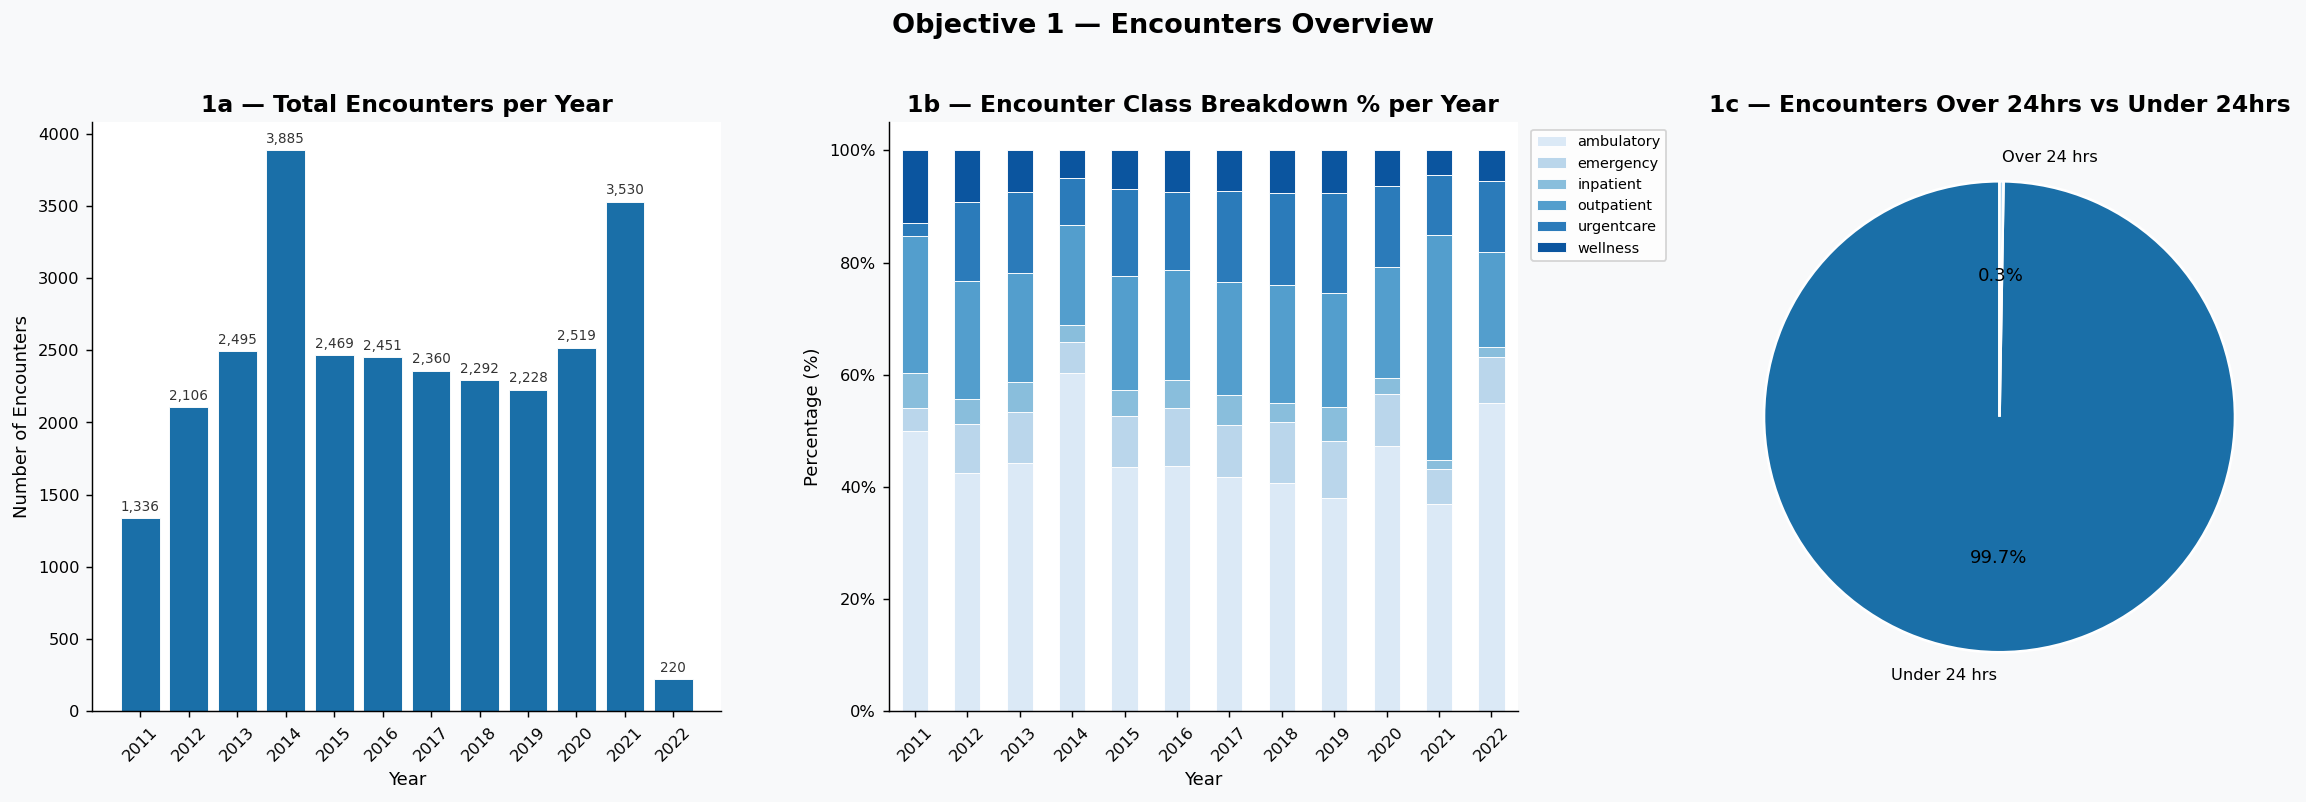

✅ Objective 1 charts saved and displayed.

📋 1a — Encounters per Year:
 YEAR  TOTAL_ENCOUNTERS
 2011              1336
 2012              2106
 2013              2495
 2014              3885
 2015              2469
 2016              2451
 2017              2360
 2018              2292
 2019              2228
 2020              2519
 2021              3530
 2022               220

📋 1c — Stay Duration Split:
   Under 24 hrs : 27,816 (99.7%)
   Over 24 hrs : 75 (0.3%)


In [5]:
# ════════════════════════════════════════════════════════
#  OBJECTIVE 1a — Total Encounters per Year
# ════════════════════════════════════════════════════════

enc_per_year = (
    encounters_df.groupby('YEAR')['Id']
    .count()
    .reset_index()
    .rename(columns={'Id': 'TOTAL_ENCOUNTERS'})
)

# ════════════════════════════════════════════════════════
#  OBJECTIVE 1b — Encounter Class Breakdown % per Year
# ════════════════════════════════════════════════════════

enc_class_year = (
    encounters_df.groupby(['YEAR', 'ENCOUNTERCLASS'])['Id']
    .count()
    .reset_index()
    .rename(columns={'Id': 'COUNT'})
)

# Calculate percentage within each year
enc_class_year['PCT'] = (
    enc_class_year.groupby('YEAR')['COUNT']
    .transform(lambda x: x / x.sum() * 100)
)

# Pivot for stacked bar
enc_class_pivot = enc_class_year.pivot(
    index='YEAR',
    columns='ENCOUNTERCLASS',
    values='PCT'
).fillna(0)

# ════════════════════════════════════════════════════════
#  OBJECTIVE 1c — Over 24hrs vs Under 24hrs
# ════════════════════════════════════════════════════════

encounters_df['STAY_CATEGORY'] = encounters_df['LOS_HOURS'].apply(
    lambda x: 'Over 24 hrs' if x > 24 else 'Under 24 hrs'
)

stay_counts = encounters_df['STAY_CATEGORY'].value_counts()

# ════════════════════════════════════════════════════════
#  PLOTTING — 3 charts in one figure
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Objective 1 — Encounters Overview', 
             fontsize=15, fontweight='bold', y=1.02)

# ── Chart 1a — Bar chart: Total Encounters per Year ──────
ax1 = axes[0]
bars = ax1.bar(
    enc_per_year['YEAR'],
    enc_per_year['TOTAL_ENCOUNTERS'],
    color=COLOR_MAIN, edgecolor='white', linewidth=0.5
)
ax1.set_title('1a — Total Encounters per Year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Encounters')
ax1.set_xticks(enc_per_year['YEAR'])
ax1.set_xticklabels(enc_per_year['YEAR'], rotation=45)

# Add value labels on bars
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=7.5, color='#333333'
    )

# ── Chart 1b — Stacked bar: Class Breakdown % per Year ───
ax2 = axes[1]
class_colors = sns.color_palette('Blues', len(enc_class_pivot.columns))
enc_class_pivot.plot(
    kind='bar', stacked=True,
    ax=ax2, color=class_colors,
    edgecolor='white', linewidth=0.5
)
ax2.set_title('1b — Encounter Class Breakdown % per Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Percentage (%)')
ax2.set_xticklabels(enc_class_pivot.index, rotation=45)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

# ── Chart 1c — Pie: Over vs Under 24hrs ──────────────────
ax3 = axes[2]
ax3.pie(
    stay_counts,
    labels=stay_counts.index,
    autopct='%1.1f%%',
    colors=[COLOR_MAIN, '#AED6F1'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax3.set_title('1c — Encounters Over 24hrs vs Under 24hrs')

plt.tight_layout()
plt.savefig('objective1_encounters_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Objective 1 charts saved and displayed.')

# ── Print summary tables ──────────────────────────────────
print('\n📋 1a — Encounters per Year:')
print(enc_per_year.to_string(index=False))

print('\n📋 1c — Stay Duration Split:')
for cat, cnt in stay_counts.items():
    pct = cnt / total_encounters * 100
    print(f'   {cat} : {cnt:,} ({pct:.1f}%)')

## Objective 2 — Cost & Coverage Insights

In this section we analyze the financial side of hospital encounters
and procedures across four angles:

### Questions we answer:
| # | Question |
|---|---|
| 2a | How many encounters had zero payer coverage, and what % of total? |
| 2b | What are the top 10 most frequent procedures and their avg cost? |
| 2c | What are the top 10 most expensive procedures and their frequency? |
| 2d | What is the average total claim cost per payer? |

### Charts we will produce:
| # | Chart Type   | Title |
|---|---|---|
| 2a | KPI text + bar | Zero Coverage Encounters by Year |
| 2b | Horizontal bar | Top 10 Most Frequent Procedures |
| 2c | Horizontal bar | Top 10 Most Expensive Procedures |
| 2d | Horizontal bar | Avg. Claim Cost by Payer |

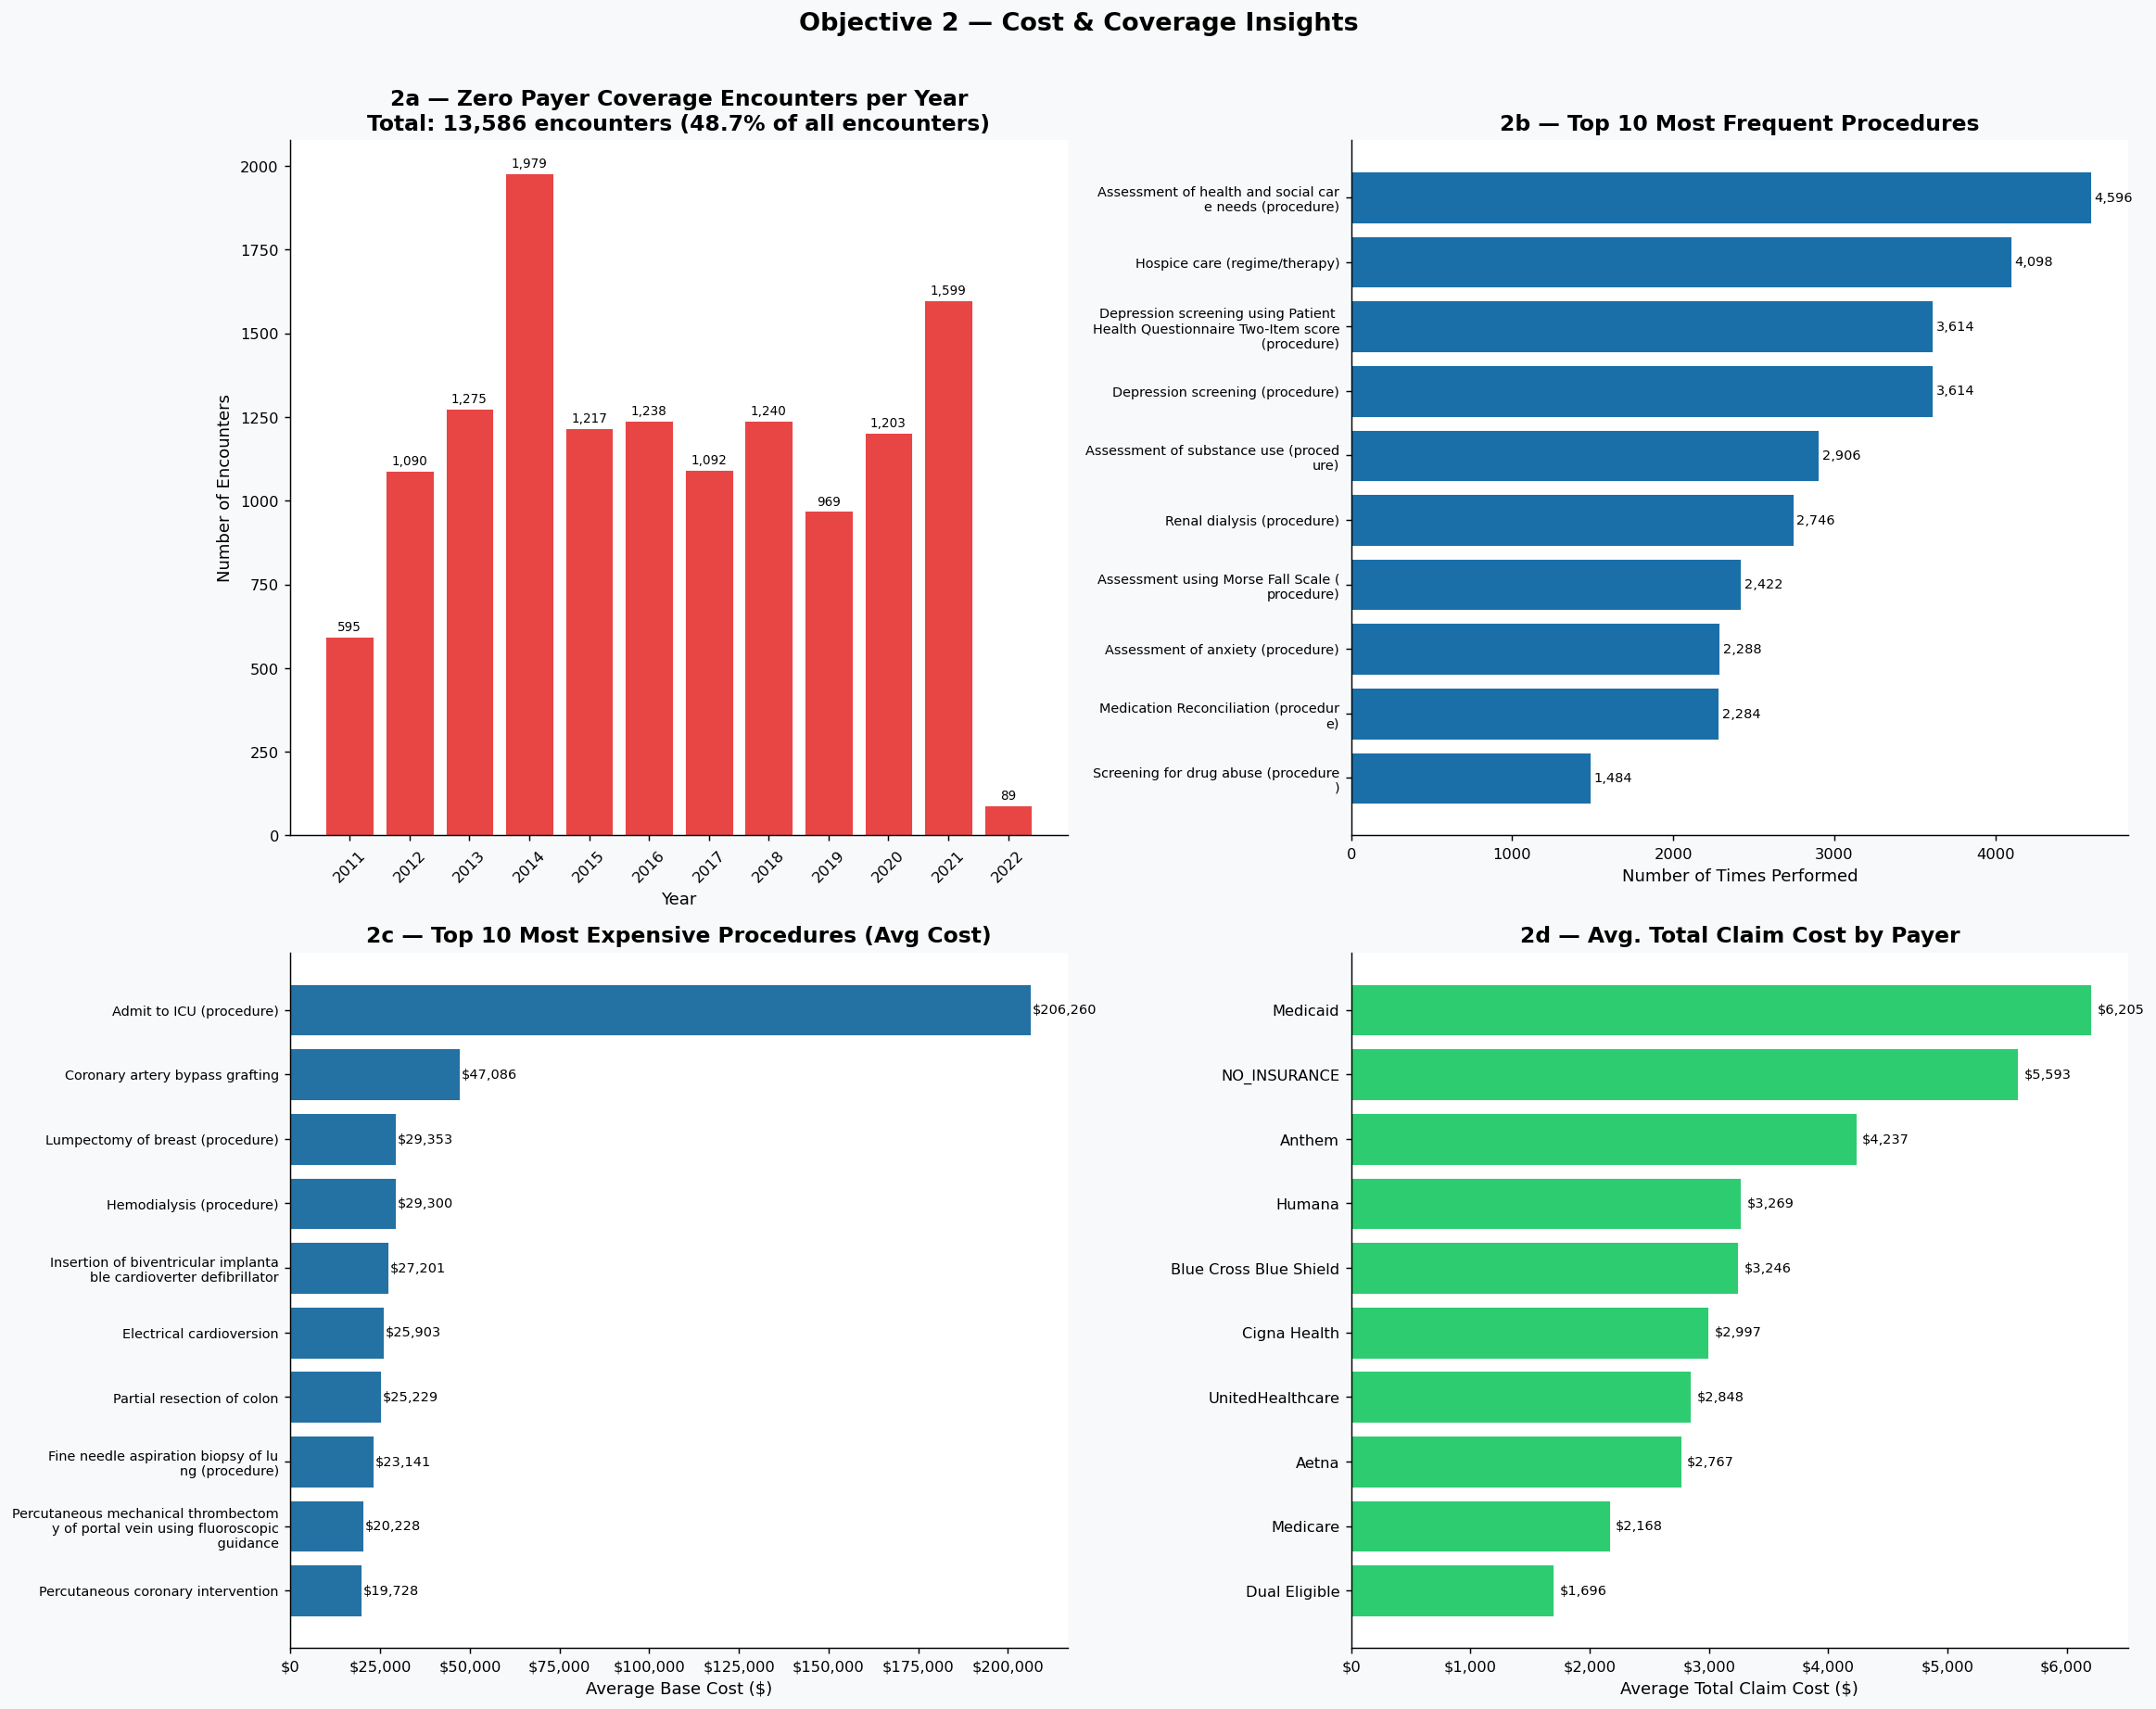

✅ Objective 2 charts saved and displayed.

📋 2a — Zero Coverage: 13,586 encounters (48.7%)

📋 2b — Top 10 Most Frequent Procedures:
                                                                       DESCRIPTION  COUNT  AVG_COST
                            Assessment of health and social care needs (procedure)   4596    431.00
                                                     Hospice care (regime/therapy)   4098    431.00
                                                  Depression screening (procedure)   3614    431.00
Depression screening using Patient Health Questionnaire Two-Item score (procedure)   3614    431.00
                                           Assessment of substance use (procedure)   2906    431.00
                                                        Renal dialysis (procedure)   2746  1,004.09
                                     Assessment using Morse Fall Scale (procedure)   2422    431.00
                                                 Assessment of anxie

In [6]:
# ════════════════════════════════════════════════════════
#  OBJECTIVE 2a — Zero Payer Coverage Encounters
# ════════════════════════════════════════════════════════

zero_coverage      = encounters_df[encounters_df['PAYER_COVERAGE'] == 0]
zero_coverage_count = len(zero_coverage)
zero_coverage_pct  = zero_coverage_count / total_encounters * 100

zero_cov_by_year   = (
    zero_coverage.groupby('YEAR')['Id']
    .count()
    .reset_index()
    .rename(columns={'Id': 'ZERO_COVERAGE'})
)

# ════════════════════════════════════════════════════════
#  OBJECTIVE 2b — Top 10 Most Frequent Procedures
# ════════════════════════════════════════════════════════

top10_frequent = (
    procedures_df.groupby('DESCRIPTION')
    .agg(
        COUNT    = ('DESCRIPTION', 'count'),
        AVG_COST = ('BASE_COST', 'mean')
    )
    .reset_index()
    .sort_values('COUNT', ascending=False)
    .head(10)
)

# ════════════════════════════════════════════════════════
#  OBJECTIVE 2c — Top 10 Most Expensive Procedures
# ════════════════════════════════════════════════════════

top10_expensive = (
    procedures_df.groupby('DESCRIPTION')
    .agg(
        AVG_COST = ('BASE_COST', 'mean'),
        COUNT    = ('DESCRIPTION', 'count')
    )
    .reset_index()
    .sort_values('AVG_COST', ascending=False)
    .head(10)
)

# ════════════════════════════════════════════════════════
#  OBJECTIVE 2d — Avg Claim Cost by Payer
# ════════════════════════════════════════════════════════

cost_by_payer = (
    encounters_df.merge(
        payers_df[['Id', 'NAME']],
        left_on='PAYER', right_on='Id',
        how='left'
    )
    .groupby('NAME')['TOTAL_CLAIM_COST']
    .mean()
    .reset_index()
    .rename(columns={'NAME': 'PAYER_NAME',
                     'TOTAL_CLAIM_COST': 'AVG_CLAIM_COST'})
    .sort_values('AVG_CLAIM_COST', ascending=True)
)

# ════════════════════════════════════════════════════════
#  PLOTTING — 2x2 layout
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Objective 2 — Cost & Coverage Insights',
             fontsize=15, fontweight='bold', y=1.01)

# ── Chart 2a — Zero Coverage by Year ─────────────────────
ax1 = axes[0, 0]
bars = ax1.bar(
    zero_cov_by_year['YEAR'],
    zero_cov_by_year['ZERO_COVERAGE'],
    color=COLOR_ACC, edgecolor='white', linewidth=0.5
)
ax1.set_title(f'2a — Zero Payer Coverage Encounters per Year\n'
              f'Total: {zero_coverage_count:,} encounters '
              f'({zero_coverage_pct:.1f}% of all encounters)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Encounters')
ax1.set_xticks(zero_cov_by_year['YEAR'])
ax1.set_xticklabels(zero_cov_by_year['YEAR'], rotation=45)
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=7.5
    )

# ── Chart 2b — Top 10 Most Frequent Procedures ───────────
ax2 = axes[0, 1]
top10_frequent_sorted = top10_frequent.sort_values('COUNT')
bars2 = ax2.barh(
    top10_frequent_sorted['DESCRIPTION'],
    top10_frequent_sorted['COUNT'],
    color=COLOR_MAIN, edgecolor='white', linewidth=0.5
)
ax2.set_title('2b — Top 10 Most Frequent Procedures')
ax2.set_xlabel('Number of Times Performed')
for bar in bars2:
    ax2.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width()):,}',
        va='center', fontsize=8
    )

# Wrap long labels
labels = [label.get_text() for label in ax2.get_yticklabels()]
wrapped = ['\n'.join(l[i:i+35] for i in range(0, len(l), 35))
           for l in labels]
ax2.set_yticklabels(wrapped, fontsize=8)

# ── Chart 2c — Top 10 Most Expensive Procedures ──────────
ax3 = axes[1, 0]
top10_expensive_sorted = top10_expensive.sort_values('AVG_COST')
bars3 = ax3.barh(
    top10_expensive_sorted['DESCRIPTION'],
    top10_expensive_sorted['AVG_COST'],
    color='#2471A3', edgecolor='white', linewidth=0.5
)
ax3.set_title('2c — Top 10 Most Expensive Procedures (Avg Cost)')
ax3.set_xlabel('Average Base Cost ($)')
ax3.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
for bar in bars3:
    ax3.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'${bar.get_width():,.0f}',
        va='center', fontsize=8
    )
labels3 = [label.get_text() for label in ax3.get_yticklabels()]
wrapped3 = ['\n'.join(l[i:i+35] for i in range(0, len(l), 35))
            for l in labels3]
ax3.set_yticklabels(wrapped3, fontsize=8)

# ── Chart 2d — Avg Claim Cost by Payer ───────────────────
ax4 = axes[1, 1]
bars4 = ax4.barh(
    cost_by_payer['PAYER_NAME'],
    cost_by_payer['AVG_CLAIM_COST'],
    color=COLOR_OK, edgecolor='white', linewidth=0.5
)
ax4.set_title('2d — Avg. Total Claim Cost by Payer')
ax4.set_xlabel('Average Total Claim Cost ($)')
ax4.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
for bar in bars4:
    ax4.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f'${bar.get_width():,.0f}',
        va='center', fontsize=8
    )

plt.tight_layout()
plt.savefig('objective2_cost_coverage.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Objective 2 charts saved and displayed.')

# ── Print summary tables ──────────────────────────────────
print(f'\n📋 2a — Zero Coverage: {zero_coverage_count:,} encounters '
      f'({zero_coverage_pct:.1f}%)')

print('\n📋 2b — Top 10 Most Frequent Procedures:')
print(top10_frequent[['DESCRIPTION','COUNT','AVG_COST']]
      .to_string(index=False))

print('\n📋 2c — Top 10 Most Expensive Procedures:')
print(top10_expensive[['DESCRIPTION','AVG_COST','COUNT']]
      .to_string(index=False))

print('\n📋 2d — Avg Claim Cost by Payer:')
print(cost_by_payer.to_string(index=False))

## Objective 3 — Patient Behavior Analysis

In this section we analyze patient admission patterns and readmission
behavior across three angles:

### Questions we answer:
| # | Question |
|---|---|
| 3a | How many unique patients were admitted each quarter over time? |
| 3b | How many patients were readmitted within 30 days of a previous encounter? |
| 3c | Which patients had the most readmissions? |

### Charts we will produce:
| # | Chart Type   | Title |
|---|---|---|
| 3a | Line chart   | Unique Patients Admitted per Quarter (2011–2022) |
| 3b | KPI + bar    | 30-Day Readmissions per Year |
| 3c | Horizontal bar | Top 15 Patients by Readmission Count |

### Methodology — 30-Day Readmission:
A patient is considered readmitted within 30 days if the START date
of a new encounter falls within 30 days after the STOP date
of a previous encounter by the same patient.

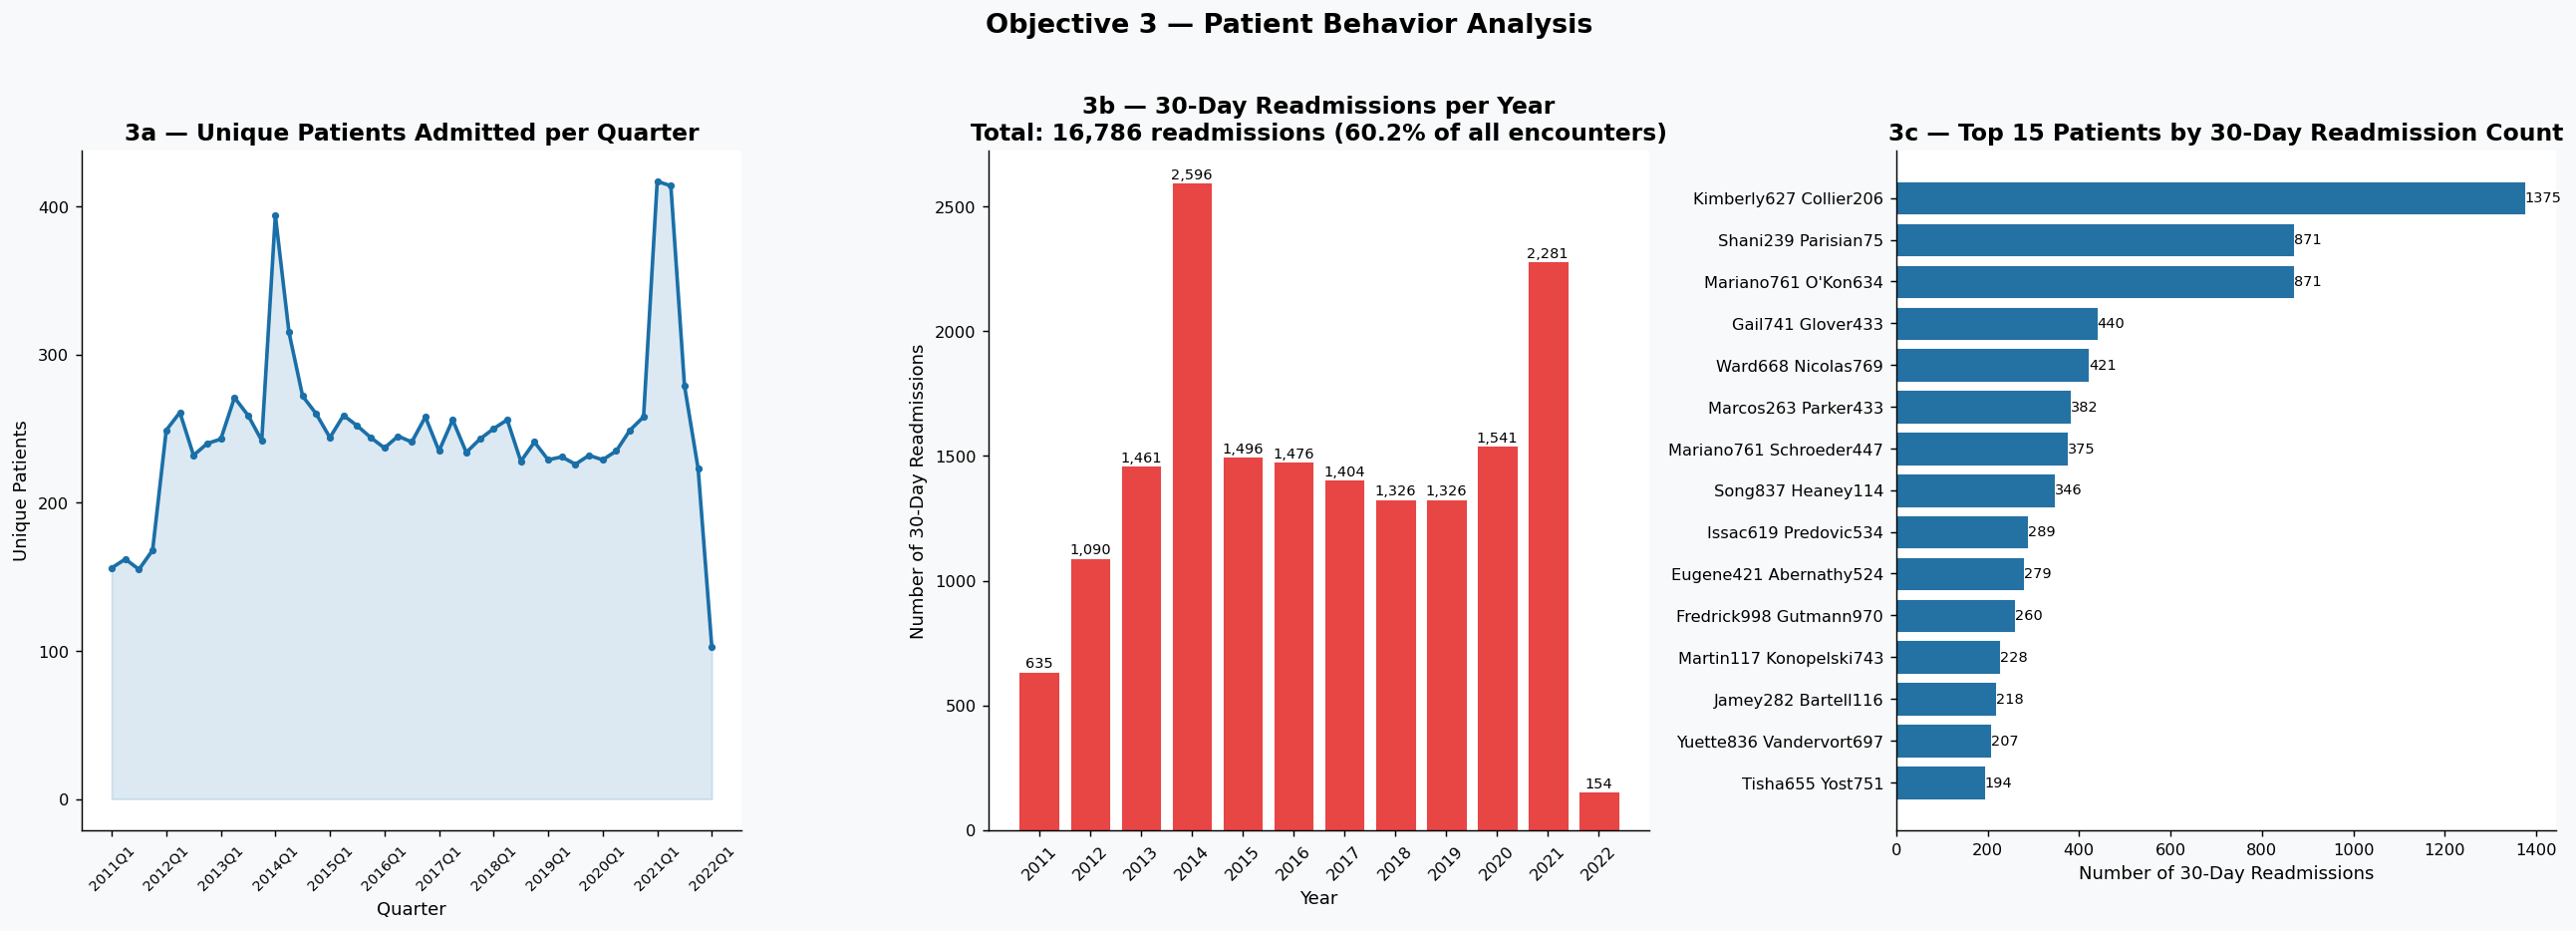

✅ Objective 3 charts saved and displayed.

📋 3b — Total 30-Day Readmissions : 16,786 (60.2%)

📋 3c — Top 15 Most Readmitted Patients:
           PATIENT_NAME  READMIT_COUNT
 Kimberly627 Collier206           1375
    Mariano761 O'Kon634            871
    Shani239 Parisian75            871
      Gail741 Glover433            440
     Ward668 Nicolas769            421
    Marcos263 Parker433            382
Mariano761 Schroeder447            375
      Song837 Heaney114            346
   Issac619 Predovic534            289
 Eugene421 Abernathy524            279
 Fredrick998 Gutmann970            260
Martin117 Konopelski743            228
    Jamey282 Bartell116            218
Yuette836 Vandervort697            207
       Tisha655 Yost751            194


In [7]:
# ════════════════════════════════════════════════════════
#  OBJECTIVE 3a — Unique Patients per Quarter
# ════════════════════════════════════════════════════════

encounters_df['QUARTER'] = encounters_df['START'].dt.to_period('Q')

patients_per_quarter = (
    encounters_df.groupby('QUARTER')['PATIENT']
    .nunique()
    .reset_index()
    .rename(columns={'PATIENT': 'UNIQUE_PATIENTS'})
)
# Convert Period to string for plotting
patients_per_quarter['QUARTER_STR'] = (
    patients_per_quarter['QUARTER'].astype(str)
)

# ════════════════════════════════════════════════════════
#  OBJECTIVE 3b — 30-Day Readmissions
# ════════════════════════════════════════════════════════

# Sort encounters by patient and start date
enc_sorted = encounters_df.sort_values(['PATIENT', 'START'])

# Calculate days since previous encounter STOP for same patient
enc_sorted['PREV_STOP'] = (
    enc_sorted.groupby('PATIENT')['STOP'].shift(1)
)
enc_sorted['DAYS_SINCE_PREV'] = (
    enc_sorted['START'] - enc_sorted['PREV_STOP']
).dt.total_seconds() / 86400

# Flag 30-day readmissions
enc_sorted['IS_30DAY_READMIT'] = (
    enc_sorted['DAYS_SINCE_PREV'].between(0, 30)
)

total_30day       = enc_sorted['IS_30DAY_READMIT'].sum()
total_30day_pct   = total_30day / total_encounters * 100

readmit_by_year = (
    enc_sorted[enc_sorted['IS_30DAY_READMIT']]
    .groupby('YEAR')['Id']
    .count()
    .reset_index()
    .rename(columns={'Id': 'READMISSIONS_30D'})
)

# ════════════════════════════════════════════════════════
#  OBJECTIVE 3c — Top 15 Patients by Readmission Count
# ════════════════════════════════════════════════════════

top_readmitted = (
    enc_sorted[enc_sorted['IS_30DAY_READMIT']]
    .groupby('PATIENT')['Id']
    .count()
    .reset_index()
    .rename(columns={'Id': 'READMIT_COUNT'})
    .sort_values('READMIT_COUNT', ascending=False)
    .head(15)
)

# Merge with patients to get names
top_readmitted = top_readmitted.merge(
    patients_df[['Id', 'FIRST', 'LAST']],
    left_on='PATIENT', right_on='Id',
    how='left'
)
top_readmitted['PATIENT_NAME'] = (
    top_readmitted['FIRST'] + ' ' + top_readmitted['LAST']
)

# ════════════════════════════════════════════════════════
#  PLOTTING — 3 charts
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Objective 3 — Patient Behavior Analysis',
             fontsize=15, fontweight='bold', y=1.02)

# ── Chart 3a — Unique Patients per Quarter ───────────────
ax1 = axes[0]
ax1.plot(
    patients_per_quarter['QUARTER_STR'],
    patients_per_quarter['UNIQUE_PATIENTS'],
    color=COLOR_MAIN, linewidth=2, marker='o', markersize=3
)
ax1.fill_between(
    patients_per_quarter['QUARTER_STR'],
    patients_per_quarter['UNIQUE_PATIENTS'],
    alpha=0.15, color=COLOR_MAIN
)
ax1.set_title('3a — Unique Patients Admitted per Quarter')
ax1.set_xlabel('Quarter')
ax1.set_ylabel('Unique Patients')
# Show every 4th label to avoid crowding
ticks = range(0, len(patients_per_quarter), 4)
ax1.set_xticks(list(ticks))
ax1.set_xticklabels(
    [patients_per_quarter['QUARTER_STR'].iloc[i] for i in ticks],
    rotation=45, fontsize=8
)

# ── Chart 3b — 30-Day Readmissions per Year ──────────────
ax2 = axes[1]
bars = ax2.bar(
    readmit_by_year['YEAR'],
    readmit_by_year['READMISSIONS_30D'],
    color=COLOR_ACC, edgecolor='white', linewidth=0.5
)
ax2.set_title(f'3b — 30-Day Readmissions per Year\n'
              f'Total: {total_30day:,} readmissions '
              f'({total_30day_pct:.1f}% of all encounters)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of 30-Day Readmissions')
ax2.set_xticks(readmit_by_year['YEAR'])
ax2.set_xticklabels(readmit_by_year['YEAR'], rotation=45)
for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=8
    )

# ── Chart 3c — Top 15 Patients by Readmissions ───────────
ax3 = axes[2]
top_sorted = top_readmitted.sort_values('READMIT_COUNT')
bars3 = ax3.barh(
    top_sorted['PATIENT_NAME'],
    top_sorted['READMIT_COUNT'],
    color='#2471A3', edgecolor='white', linewidth=0.5
)
ax3.set_title('3c — Top 15 Patients by 30-Day Readmission Count')
ax3.set_xlabel('Number of 30-Day Readmissions')
for bar in bars3:
    ax3.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center', fontsize=8
    )

plt.tight_layout()
plt.savefig('objective3_patient_behavior.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Objective 3 charts saved and displayed.')

# ── Print summary tables ──────────────────────────────────
print(f'\n📋 3b — Total 30-Day Readmissions : {total_30day:,} '
      f'({total_30day_pct:.1f}%)')

print('\n📋 3c — Top 15 Most Readmitted Patients:')
print(top_readmitted[['PATIENT_NAME', 'READMIT_COUNT']]
      .to_string(index=False))

## Step 8 — Final Summary Dashboard

This final step brings together the most important KPIs and charts
from all three objectives into a single professional dashboard.

### Dashboard Layout:
| Position | Content |
|---|---|
| Top banner    | 6 KPI summary cards |
| Row 2 Left    | Total Encounters per Year (Obj 1a) |
| Row 2 Right   | Encounter Class Breakdown % (Obj 1b) |
| Row 3 Left    | Zero Coverage vs Covered by Year (Obj 2a) |
| Row 3 Right   | Avg Claim Cost by Payer (Obj 2d) |
| Row 4 Left    | Unique Patients per Quarter (Obj 3a) |
| Row 4 Right   | 30-Day Readmissions per Year (Obj 3b) |

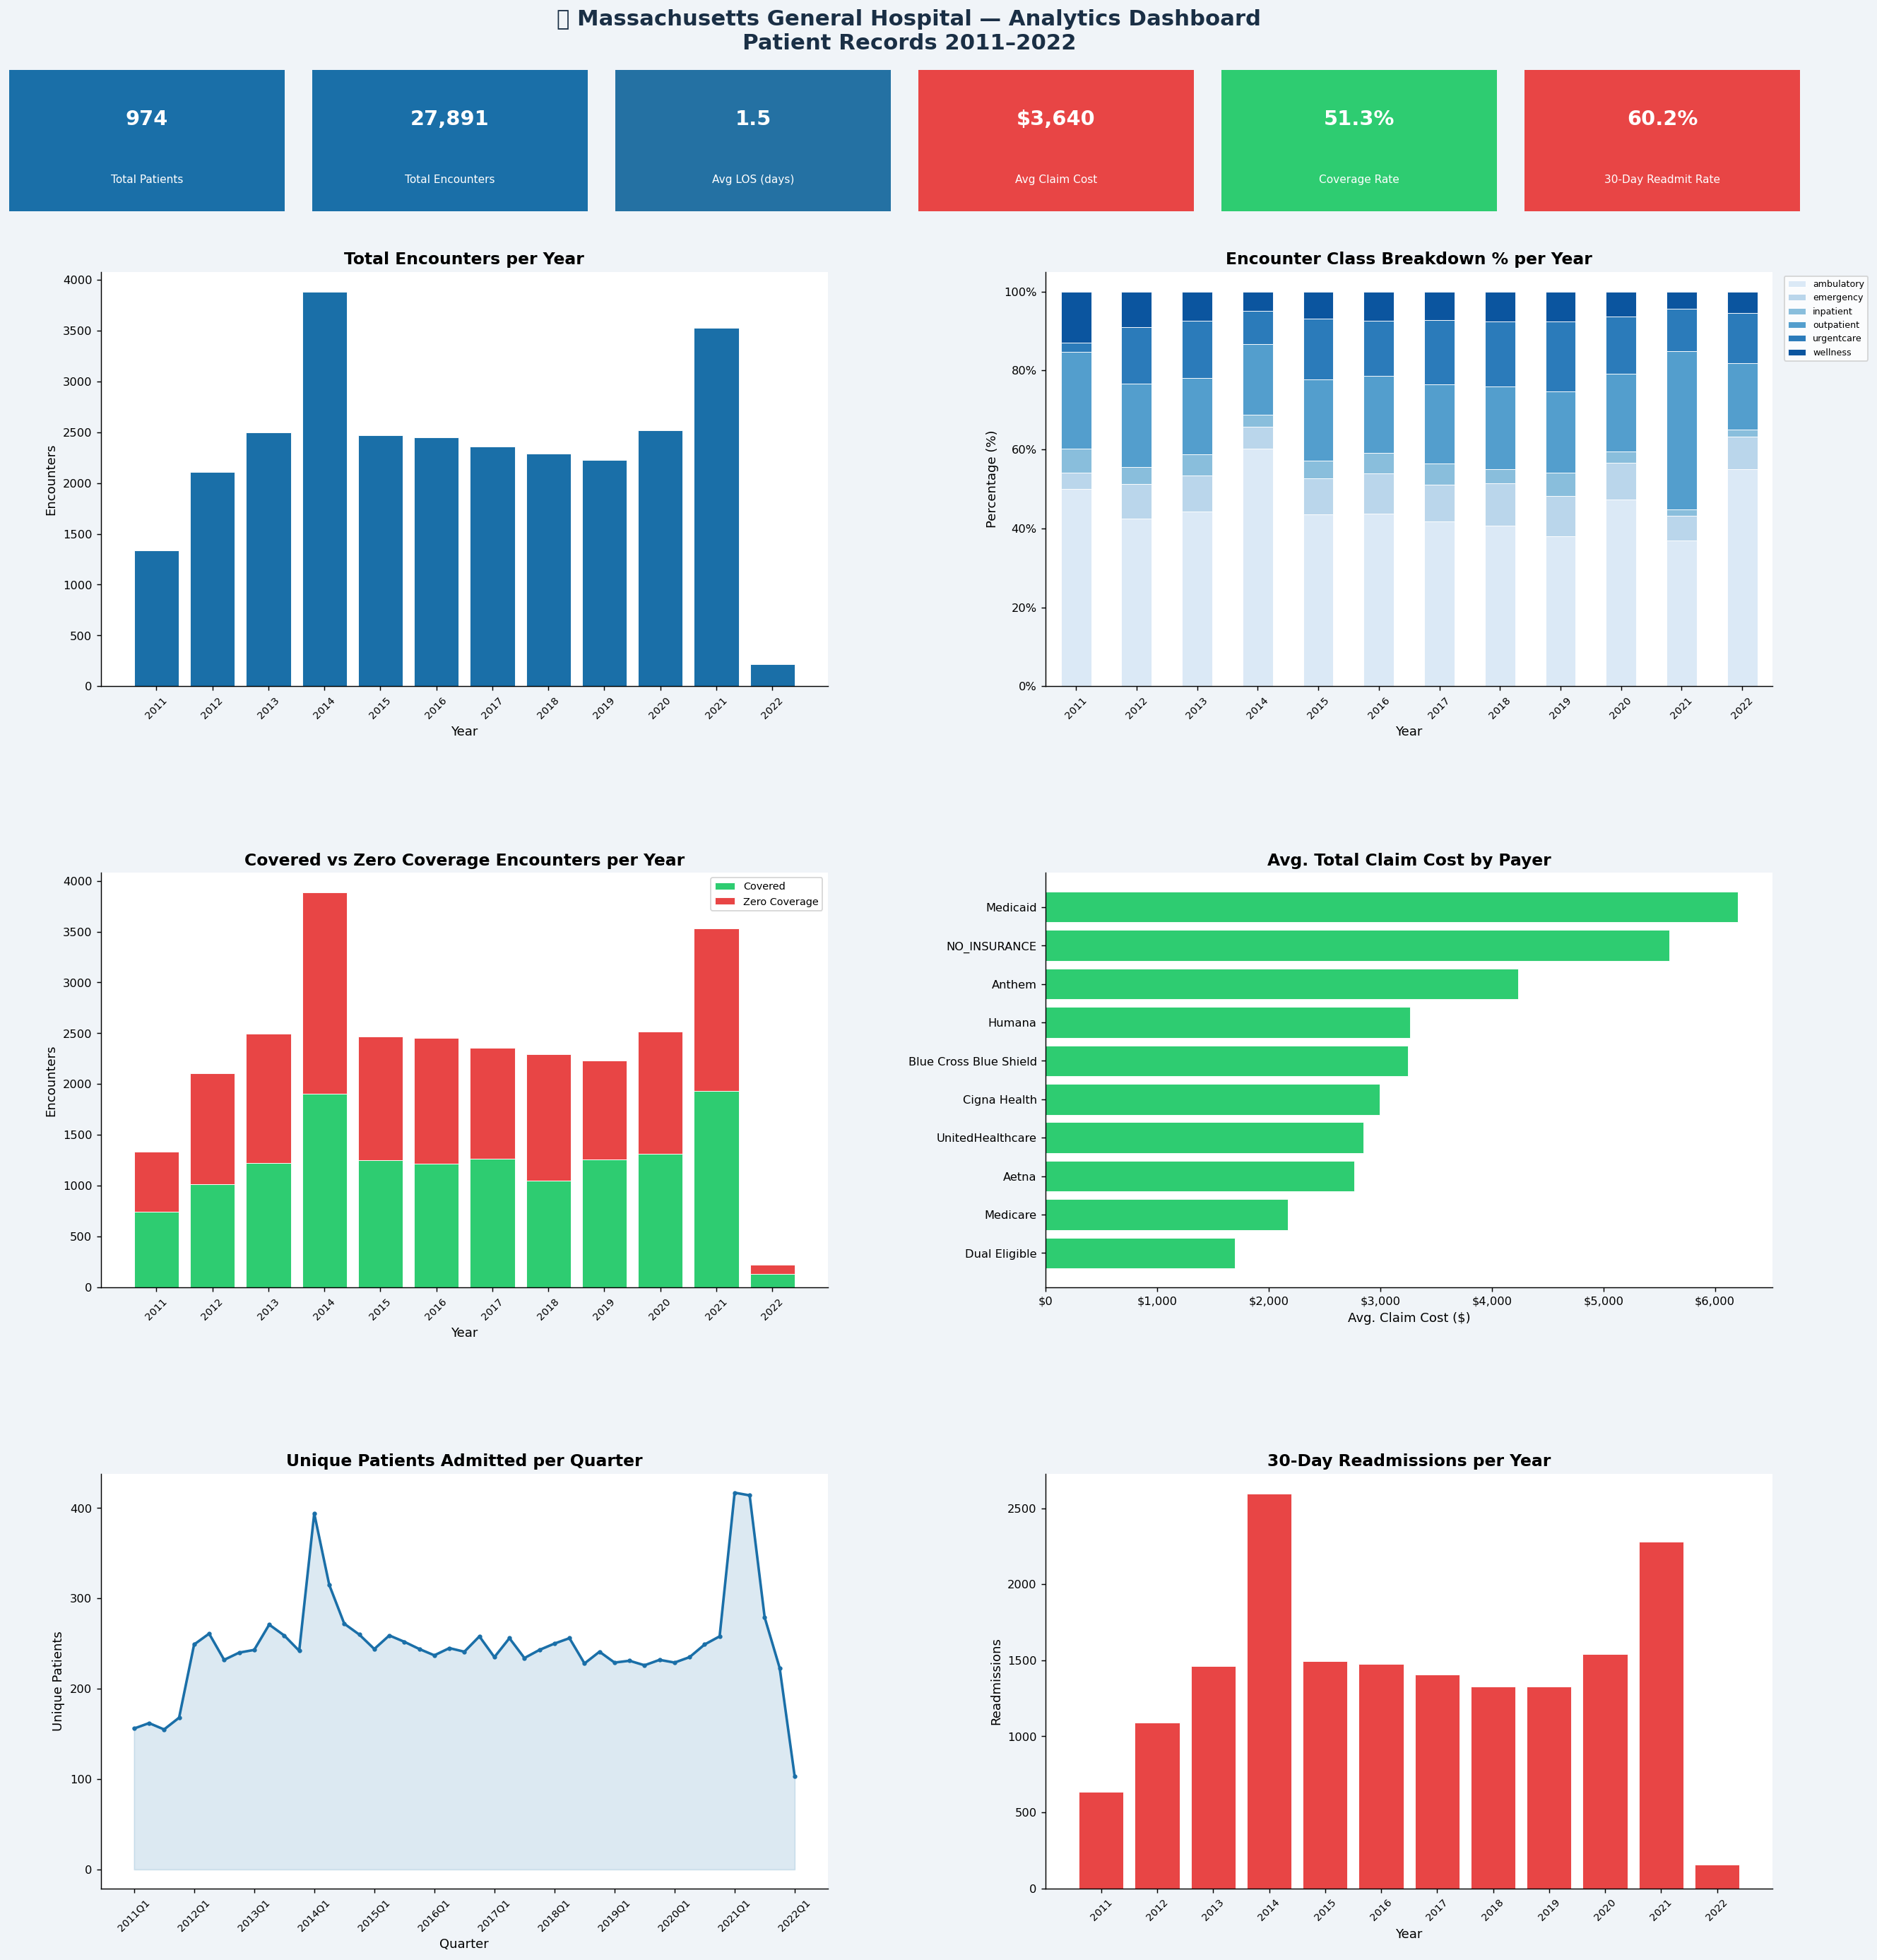

✅ Final Dashboard saved and displayed.


In [8]:
# ════════════════════════════════════════════════════════
#  FINAL SUMMARY DASHBOARD
# ════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#F0F4F8')

fig.suptitle(
    '🏥 Massachusetts General Hospital — Analytics Dashboard\n'
    'Patient Records 2011–2022',
    fontsize=17, fontweight='bold', y=0.98, color='#1A2F45'
)

# ── KPI Banner (top row) ─────────────────────────────────
kpis = [
    ('Total Patients',       f'{total_patients:,}',         '#1A6FA8'),
    ('Total Encounters',     f'{total_encounters:,}',        '#1A6FA8'),
    ('Avg LOS (days)',        f'{avg_los_days:.1f}',          '#2471A3'),
    ('Avg Claim Cost',       f'${avg_claim_cost:,.0f}',      '#E84545'),
    ('Coverage Rate',        f'{coverage_rate:.1f}%',        '#2ECC71'),
    ('30-Day Readmit Rate',  f'{total_30day_pct:.1f}%',      '#E84545'),
]

for i, (label, value, color) in enumerate(kpis):
    ax_kpi = fig.add_axes([0.01 + i * 0.165, 0.88, 0.15, 0.07])
    ax_kpi.set_facecolor(color)
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_visible(False)
    ax_kpi.text(0.5, 0.65, value, ha='center', va='center',
                fontsize=16, fontweight='bold', color='white',
                transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.22, label, ha='center', va='center',
                fontsize=8.5, color='white',
                transform=ax_kpi.transAxes)

# ── Grid of 6 charts ─────────────────────────────────────
gs = fig.add_gridspec(3, 2,
                      left=0.06, right=0.97,
                      top=0.85, bottom=0.05,
                      hspace=0.45, wspace=0.3)

# ── Chart 1 — Encounters per Year ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(enc_per_year['YEAR'], enc_per_year['TOTAL_ENCOUNTERS'],
        color=COLOR_MAIN, edgecolor='white', linewidth=0.5)
ax1.set_title('Total Encounters per Year', fontweight='bold')
ax1.set_xlabel('Year'); ax1.set_ylabel('Encounters')
ax1.set_xticks(enc_per_year['YEAR'])
ax1.set_xticklabels(enc_per_year['YEAR'], rotation=45, fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2 — Class Breakdown ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
class_colors = sns.color_palette('Blues', len(enc_class_pivot.columns))
enc_class_pivot.plot(kind='bar', stacked=True, ax=ax2,
                     color=class_colors, edgecolor='white',
                     linewidth=0.5, legend=True)
ax2.set_title('Encounter Class Breakdown % per Year', fontweight='bold')
ax2.set_xlabel('Year'); ax2.set_ylabel('Percentage (%)')
ax2.set_xticklabels(enc_class_pivot.index, rotation=45, fontsize=8)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3 — Zero vs Covered Coverage by Year ───────────
ax3 = fig.add_subplot(gs[1, 0])
covered_by_year = (
    encounters_df[encounters_df['PAYER_COVERAGE'] > 0]
    .groupby('YEAR')['Id'].count()
    .reset_index().rename(columns={'Id': 'COVERED'})
)
ax3.bar(covered_by_year['YEAR'], covered_by_year['COVERED'],
        label='Covered', color=COLOR_OK,
        edgecolor='white', linewidth=0.5)
ax3.bar(zero_cov_by_year['YEAR'], zero_cov_by_year['ZERO_COVERAGE'],
        bottom=covered_by_year['COVERED'],
        label='Zero Coverage', color=COLOR_ACC,
        edgecolor='white', linewidth=0.5)
ax3.set_title('Covered vs Zero Coverage Encounters per Year',
              fontweight='bold')
ax3.set_xlabel('Year'); ax3.set_ylabel('Encounters')
ax3.set_xticks(covered_by_year['YEAR'])
ax3.set_xticklabels(covered_by_year['YEAR'], rotation=45, fontsize=8)
ax3.legend(fontsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── Chart 4 — Avg Claim Cost by Payer ────────────────────
ax4 = fig.add_subplot(gs[1, 1])
cost_sorted = cost_by_payer.sort_values('AVG_CLAIM_COST')
ax4.barh(cost_sorted['PAYER_NAME'], cost_sorted['AVG_CLAIM_COST'],
         color=COLOR_OK, edgecolor='white', linewidth=0.5)
ax4.set_title('Avg. Total Claim Cost by Payer', fontweight='bold')
ax4.set_xlabel('Avg. Claim Cost ($)')
ax4.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── Chart 5 — Unique Patients per Quarter ────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(patients_per_quarter['QUARTER_STR'],
         patients_per_quarter['UNIQUE_PATIENTS'],
         color=COLOR_MAIN, linewidth=2, marker='o', markersize=2.5)
ax5.fill_between(patients_per_quarter['QUARTER_STR'],
                 patients_per_quarter['UNIQUE_PATIENTS'],
                 alpha=0.15, color=COLOR_MAIN)
ax5.set_title('Unique Patients Admitted per Quarter', fontweight='bold')
ax5.set_xlabel('Quarter'); ax5.set_ylabel('Unique Patients')
ticks = range(0, len(patients_per_quarter), 4)
ax5.set_xticks(list(ticks))
ax5.set_xticklabels(
    [patients_per_quarter['QUARTER_STR'].iloc[i] for i in ticks],
    rotation=45, fontsize=8)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# ── Chart 6 — 30-Day Readmissions per Year ───────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.bar(readmit_by_year['YEAR'], readmit_by_year['READMISSIONS_30D'],
        color=COLOR_ACC, edgecolor='white', linewidth=0.5)
ax6.set_title('30-Day Readmissions per Year', fontweight='bold')
ax6.set_xlabel('Year'); ax6.set_ylabel('Readmissions')
ax6.set_xticks(readmit_by_year['YEAR'])
ax6.set_xticklabels(readmit_by_year['YEAR'], rotation=45, fontsize=8)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

plt.savefig('final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Final Dashboard saved and displayed.')

## Step 9 — Conclusions & Key Findings

This analysis covered 11 years (2011–2022) of patient records at
Massachusetts General Hospital, examining 974 patients across
27,891 encounters and 47,701 procedures.

---

### 🏥 Objective 1 — Encounters Overview

| Finding | Detail |
|---|---|
| Peak activity year | 2014 with 3,885 encounters |
| Slowest period | 2019–2020 — likely COVID-19 impact |
| Strong recovery | 2021 rebounded to 3,530 encounters |
| Dominant encounter class | Ambulatory visits — consistently 50%+ every year |
| Most stays are short | 99.7% of all encounters were under 24 hours |
| True inpatient stays | Only 75 encounters exceeded 24 hours (0.3%) |
| Avg length of stay | 1.5 days for inpatient encounters |

> 💡 The hospital primarily serves outpatient and ambulatory patients.
> True overnight admissions are rare and represent a very small fraction
> of total activity.

---

### 💰 Objective 2 — Cost & Coverage Insights

| Finding | Detail |
|---|---|
| Zero coverage encounters | 13,586 encounters — 48.7% of all visits ⚠️ |
| Average claim cost | $3,639.68 per encounter |
| Average out-of-pocket | $2,524.72 per encounter |
| Insurance coverage rate | Only 51.3% of encounters had any payer coverage |
| Most frequent procedure | Assessment of health & social care needs (4,596 times) |
| Most expensive procedure | Admit to ICU — avg $206,260 (performed only 5 times) |
| Highest cost payer | Medicaid at $6,205 avg claim cost |
| Lowest cost payer | Dual Eligible at $1,596 avg claim cost |
| Most performed costly procedure | Electrical cardioversion — $25,903 avg, 1,383 times |

> 💡 The most critical financial finding is that nearly half of all
> encounters had zero insurance coverage, leaving patients with an
> average out-of-pocket burden of $2,524 per visit. This represents
> a major financial risk for both patients and the hospital.

---

### 👥 Objective 3 — Patient Behavior Analysis

| Finding | Detail |
|---|---|
| Avg encounters per patient | 28.6 visits over 11 years |
| Overall readmission rate | 87.7% of patients returned more than once |
| 30-day readmission rate | 16,786 encounters (60.2%) ⚠️ |
| Peak readmission year | 2014 with 2,558 readmissions |
| COVID impact | Clear dip in unique patients in 2019–2020 |
| Most readmitted patient | Kimberly627 Collier206 — 1,375 readmissions |
| Top 3 patients | Account for 3,117 combined 30-day readmissions |

> 💡 The 60.2% thirty-day readmission rate is very high and strongly
> suggests a patient population dominated by chronic conditions such
> as renal failure, heart disease, and end-of-life care — all of which
> require frequent and repeated hospital visits by nature.

---

### 🎯 Top 3 Recommendations

1. **Address the Insurance Coverage Gap**
   Nearly half of all encounters have zero payer coverage.
   The hospital should explore financial assistance programs,
   Medicaid enrollment support, and payment plan options
   to reduce the burden on uninsured patients.

2. **Focus on High-Readmission Patients**
   The top 15 readmitted patients account for a disproportionate
   share of all encounters. A dedicated chronic care management
   program targeting these patients could significantly reduce
   unnecessary readmissions and hospital costs.

3. **Monitor Post-COVID Recovery**
   The 2021 rebound in encounters and admissions after the
   2019–2020 COVID dip is promising, but the 2022 data is
   incomplete. A full-year 2022 and 2023 analysis should be
   conducted to confirm the recovery trend is sustained.

---

### 📌 Data Notes

- The 2022 data is **incomplete** (only 220 encounters) and should
  not be used for year-over-year comparisons.
- Patient names in this dataset are **synthetic** (Synthea generator)
  and do not represent real individuals.
- All financial figures are in **USD**.

---

*Analysis completed by Dr. Bahaa — Bahaa Pharmacy, Data Analytics Division*
*May 2026*